In [1]:
from pathlib import Path

import pandas as pd
from tqdm import tqdm

from utils import (
    asymmetric_late_prediction_weights,
    time_to_event_training_weights,
    train_models_for_target,
)

/home/aj/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [2]:
DATA_DIR = Path("output")
CSV_PATTERN = "dataset_winsize*.csv"

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
EARLY_PREDICTION_COST = 1.0
LATE_PREDICTION_COST = 5.0


def regression_metric_weight_fn(y_true, y_pred):
    return asymmetric_late_prediction_weights(
        y_true,
        y_pred,
        early_prediction_cost=EARLY_PREDICTION_COST,
        late_prediction_cost=LATE_PREDICTION_COST,
    )


REGRESSION_WEIGHTING_RUNS = [
    {
        "weighting_name": "unweighted",
        "sample_weight_fn": None,
        "metric_weight_fn": regression_metric_weight_fn,
    },
    {
        "weighting_name": "weighted",
        "sample_weight_fn": lambda y: time_to_event_training_weights(
            y,
            early_prediction_cost=EARLY_PREDICTION_COST,
            late_prediction_cost=LATE_PREDICTION_COST,
        ),
        "metric_weight_fn": regression_metric_weight_fn,
    },
]

TARGETS = {
    "label_time_to_event_seconds": "regression",
    "label_from_zone": "classification",
    "label_to_zone": "classification",
}

DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]

SUMMARY_FILENAME = "all_metrics_summary.csv"

MODEL_LABELS = {"tree": "Tree", "rf": "Random Forest"}

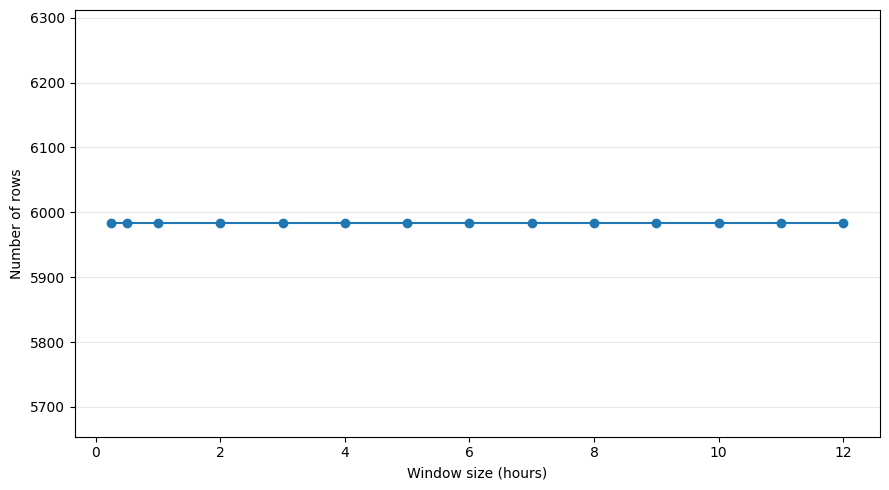

,dataset,winsize,winsize_hours,num_rows
0,dataset_winsize0.25h,0.25,0.25,5983
1,dataset_winsize0.5h,0.5,0.50,5983
2,dataset_winsize1h,1,1.00,5983
3,dataset_winsize2h,2,2.00,5983
4,dataset_winsize3h,3,3.00,5983
5,dataset_winsize4h,4,4.00,5983
6,dataset_winsize5h,5,5.00,5983
7,dataset_winsize6h,6,6.00,5983
8,dataset_winsize7h,7,7.00,5983
9,dataset_winsize8h,8,8.00,5983


In [3]:
import matplotlib.pyplot as plt

row_counts = []

for csv_path in sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
):
    df = pd.read_csv(csv_path)
    winsize = csv_path.stem.split("winsize", 1)[1].removesuffix("h")
    row_counts.append(
        {
            "dataset": csv_path.stem,
            "winsize": winsize,
            "winsize_hours": float(winsize),
            "num_rows": len(df),
        }
    )

row_counts_df = pd.DataFrame(row_counts).sort_values("winsize_hours")

ax = row_counts_df.plot(
    x="winsize_hours",
    y="num_rows",
    kind="line",
    marker="o",
    figsize=(9, 5),
    legend=False,
)
ax.set_xlabel("Window size (hours)")
ax.set_ylabel("Number of rows")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

row_counts_df

In [4]:
############
# RUN ONCE #
############
# Main loop over datasets (takes abut 30 minutes)

# """
all_results = []

csv_files = sorted(
    DATA_DIR.glob(CSV_PATTERN),
    key=lambda p: float(p.stem.split("winsize", 1)[1].removesuffix("h")),
)

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No files found matching {CSV_PATTERN} in {DATA_DIR.resolve()}"
    )

for csv_path in tqdm(csv_files):
    dataset_name = csv_path.stem
    print(f"\nReading {csv_path}")

    df = pd.read_csv(csv_path)

    for target_col, task_type in TARGETS.items():
        weighting_runs = (
            REGRESSION_WEIGHTING_RUNS
            if task_type == "regression"
            else [
                {
                    "weighting_name": None,
                    "sample_weight_fn": None,
                    "metric_weight_fn": None,
                }
            ]
        )

        for weighting_run in weighting_runs:
            metrics_df = train_models_for_target(
                df=df,
                dataset_name=dataset_name,
                target_col=target_col,
                task_type=task_type,
                output_dir=OUTPUT_DIR,
                random_state=RANDOM_STATE,
                drop_columns=DROP_COLUMNS,
                sample_weight_fn=weighting_run["sample_weight_fn"],
                metric_weight_fn=weighting_run["metric_weight_fn"],
                weighting_name=weighting_run["weighting_name"],
            )

            all_results.append(metrics_df)

final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

print("\nFinal summary:")
print(final_results)
# """

  0%|          | 0/14 [00:00<?, ?it/s]


Reading output/dataset_winsize0.25h.csv

Dataset: dataset_winsize0.25h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5325.690109009958, 'median_absolute_error': 737.8834498834499, 'mse': 132982924.74045248, 'rmse': np.float64(11531.822264518842), 'r2': 0.4488599062614649, 'weighted_mae': 4780.276983273515, 'weighted_median_absolute_error': 762.1165501165501, 'weighted_mse': 80796178.8683764, 'weighted_rmse': np.float64(8988.66947152783), 'weighted_r2': 0.262641242306212, 'cost_mae': np.float64(16137.927560073746), 'cost_mse': np.float64(272763039.93910533), 'cost_rmse': np.float64(16515.539347508617), 'cost_mean_weight': np.float64(3.3759398496240602), 'late_prediction_rate': np.float64(0.5939849624060151), 'late_prediction_count': 711}

Top built-in feature importances for tree:
                    feature  importance
15  num_events_last_120_min    0.924697
14   num_events_last_60_min    0.016487
16         node_degree_mean    0.

  7%|▋         | 1/14 [01:10<15:17, 70.56s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.006106
3           num_115kv_lines       0.005735
17          node_degree_std       0.005399
4           num_132kv_lines       0.005131
19          node_degree_max       0.004982
15  num_events_last_120_min       0.004960
18          node_degree_min       0.004028
12   num_events_last_15_min       0.003947
14   num_events_last_60_min       0.003799
13   num_events_last_30_min       0.003131

Reading output/dataset_winsize0.5h.csv

Dataset: dataset_winsize0.5h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5423.761611368275, 'median_absolute_error': 746.0495049504952, 'mse': 136206062.54240373, 'rmse': np.float64(11670.73530427298), 'r2': 0.4355017967615672, 'weighted_mae': 4812.147741315008, 'weighted_median_absolute_error': 667.4566666666669, 'weighted_mse': 82328869.78071831, 'weighted_rmse': np.float64(9073.525763490085), 

 14%|█▍        | 2/14 [02:23<14:25, 72.14s/it]

...


Top SHAP importances for rf:
                    feature  mean_abs_shap
3           num_115kv_lines       0.004803
16         node_degree_mean       0.004682
11         num_unique_buses       0.004153
17          node_degree_std       0.003991
15  num_events_last_120_min       0.003981
1          num_unique_ptids       0.003150
19          node_degree_max       0.002955
9       num_planned_outages       0.002922
0                num_events       0.002873
4           num_132kv_lines       0.002831

Reading output/dataset_winsize11h.csv

Dataset: dataset_winsize11h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5369.44239979955, 'median_absolute_error': 744.549065420561, 'mse': 137929108.83061448, 'rmse': np.float64(11744.322408322008), 'r2': 0.42836073038290434, 'weighted_mae': 4913.582297276561, 'weighted_median_absolute_error': 861.3260869565202, 'weighted_mse': 83647182.27675492, 'weighted_rmse': np.float64(9145.883351363875), 'w

 93%|█████████▎| 13/14 [17:33<01:25, 85.84s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
3           num_115kv_lines       0.004657
16         node_degree_mean       0.004560
11         num_unique_buses       0.004202
17          node_degree_std       0.004146
15  num_events_last_120_min       0.004037
1          num_unique_ptids       0.003163
9       num_planned_outages       0.002943
19          node_degree_max       0.002902
0                num_events       0.002846
4           num_132kv_lines       0.002829

Reading output/dataset_winsize12h.csv

Dataset: dataset_winsize12h
Target: label_time_to_event_seconds
Task: regression
Weighting: unweighted

Training tree...
{'mae': 5366.159001444038, 'median_absolute_error': 743.2539267015709, 'mse': 137958211.40909934, 'rmse': np.float64(11745.561349254422), 'r2': 0.42824011641787463, 'weighted_mae': 4926.43922092648, 'weighted_median_absolute_error': 809.7116788321164, 'weighted_mse': 87964581.79279418, 'weighted_rmse': np.float64(9378.94353287161), 'w

100%|██████████| 14/14 [19:02<00:00, 81.58s/it]


Top SHAP importances for rf:
                    feature  mean_abs_shap
16         node_degree_mean       0.004647
17          node_degree_std       0.004378
3           num_115kv_lines       0.004335
15  num_events_last_120_min       0.004030
11         num_unique_buses       0.003796
9       num_planned_outages       0.003169
19          node_degree_max       0.002967
14   num_events_last_60_min       0.002894
0                num_events       0.002879
1          num_unique_ptids       0.002717

Final summary:
             mae  median_absolute_error           mse          rmse        r2  \
0    5325.690109             737.883450  1.329829e+08  11531.822265  0.448860   
1    5430.596127             698.811668  1.371170e+08  11709.698329  0.431726   
2    5118.718662             738.903930  1.304404e+08  11421.048652  0.459397   
3    5311.689960             721.545663  1.370914e+08  11708.605096  0.431832   
4            NaN                    NaN           NaN           NaN       Na

In [5]:
metrics_df = pd.read_csv(OUTPUT_DIR / SUMMARY_FILENAME)
metrics_df.head()

,mae,median_absolute_error,mse,rmse,r2,weighted_mae,weighted_median_absolute_error,weighted_mse,weighted_rmse,weighted_r2,...,train_weight_mean,train_weight_max,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,5325.690109,737.883450,1.329829e+08,11531.822265,0.448860,4780.276983,762.116550,8.079618e+07,8988.669472,0.262641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5430.596127,698.811668,1.371170e+08,11709.698329,0.431726,4926.830261,742.836701,8.576875e+07,9261.141924,0.222249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5118.718662,738.903930,1.304404e+08,11421.048652,0.459397,4282.322998,738.903930,6.991446e+07,8361.486887,0.355504,...,4.810423,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5311.689960,721.545663,1.370914e+08,11708.605096,0.431832,4582.686680,735.665578,7.814367e+07,8839.891042,0.281230,...,4.810423,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.088555,0.050547,0.052361,0.050547,0.039069,0.12799,0.088555,0.078493


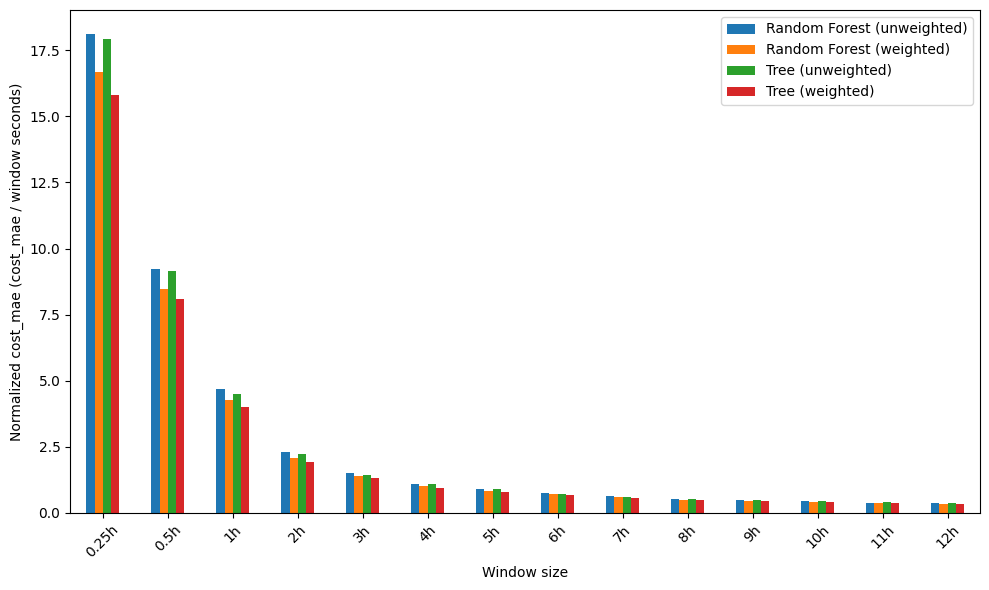

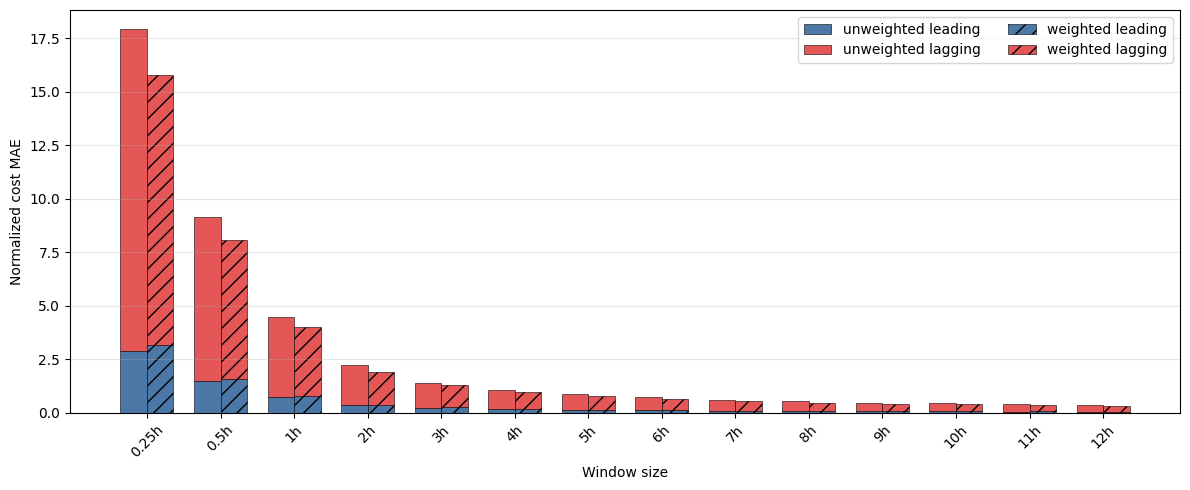

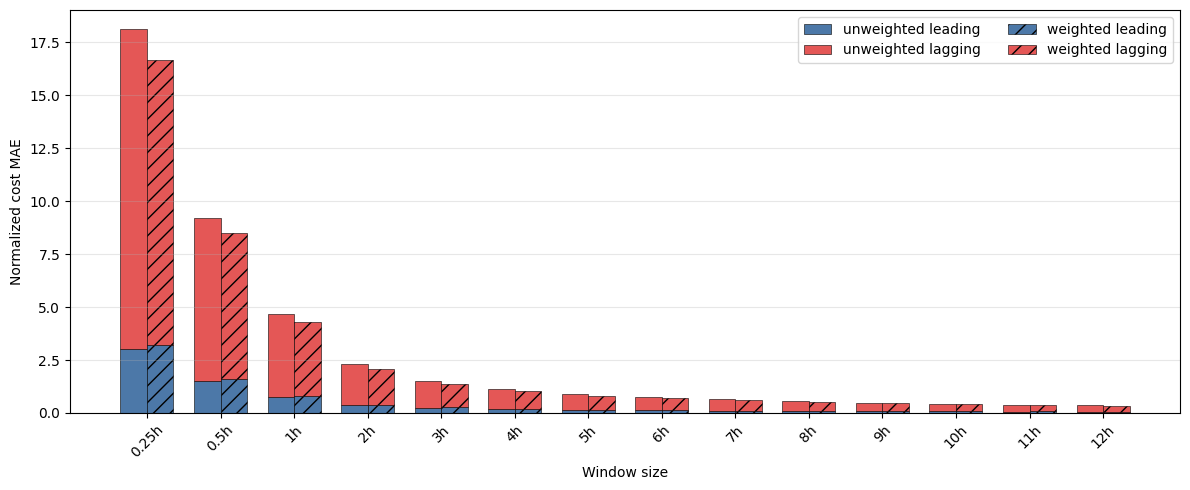

,dataset,winsize,winsize_hours,winsize_seconds,model,weighting,model_run,leading_norm_cost_mae,lagging_norm_cost_mae,normalized_cost_mae,leading_cost_mae_share,lagging_cost_mae_share,lagging_prediction_rate
0,dataset_winsize0.25h,0.25h,0.25,900.0,tree,unweighted,Tree (unweighted),2.914034,15.016996,17.931031,0.162513,0.837487,0.593985
1,dataset_winsize0.25h,0.25h,0.25,900.0,rf,unweighted,Random Forest (unweighted),3.013771,15.101122,18.114893,0.166370,0.833630,0.577277
2,dataset_winsize0.25h,0.25h,0.25,900.0,tree,weighted,Tree (weighted),3.161112,12.631768,15.792880,0.200161,0.799839,0.579783
3,dataset_winsize0.25h,0.25h,0.25,900.0,rf,weighted,Random Forest (weighted),3.211752,13.450630,16.662382,0.192755,0.807245,0.568087
4,dataset_winsize0.5h,0.5h,0.50,1800.0,tree,unweighted,Tree (unweighted),1.481144,7.660284,9.141428,0.162025,0.837975,0.604845


In [6]:
import joblib
import matplotlib.pyplot as plt
import numpy as np

reg_df = metrics_df[
    (metrics_df["task"] == "regression") & (metrics_df["model"].isin(["tree", "rf"]))
].copy()

reg_df["winsize"] = reg_df["dataset"].str.extract(r"winsize(.+)$", expand=False)
reg_df["winsize_hours"] = (
    reg_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
if "weighting" not in reg_df.columns:
    reg_df["weighting"] = "unweighted"

if "cost_mae" in reg_df.columns:
    mae_column = "cost_mae"
elif "weighted_mae" in reg_df.columns:
    mae_column = "weighted_mae"
else:
    mae_column = "mae"
reg_df["winsize_seconds"] = reg_df["winsize_hours"] * 3600
reg_df["mae_norm"] = reg_df[mae_column] / reg_df["winsize_seconds"]
reg_df["model_run"] = (
    reg_df["model"].map(MODEL_LABELS).fillna(reg_df["model"])
    + " ("
    + reg_df["weighting"].fillna("unweighted")
    + ")"
)

reg_df = reg_df.sort_values("winsize_hours")
winsize_order = reg_df.drop_duplicates("winsize")["winsize"]

pivot = reg_df.pivot(
    index="winsize",
    columns="model_run",
    values="mae_norm",
).reindex(winsize_order)

ax = pivot.plot(kind="bar", figsize=(10, 6))
ax.set_xlabel("Window size")
ax.set_ylabel(f"Normalized {mae_column} ({mae_column} / window seconds)")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    Path("output") / "regression_mae_norm_bar.pdf", dpi=300, bbox_inches="tight"
)
plt.show()


def regression_error_source_breakdown(regression_rows):
    data_dir = Path("output")
    model_output_dir = Path("model_outputs")
    target_col = "label_time_to_event_seconds"
    rows = []

    for row in regression_rows.itertuples(index=False):
        weighting = getattr(row, "weighting", "unweighted")
        weighting = "unweighted" if pd.isna(weighting) else str(weighting)
        model_path = (
            model_output_dir
            / row.dataset
            / target_col
            / weighting
            / f"{row.model}.joblib"
        )
        if not model_path.exists() and weighting == "unweighted":
            model_path = (
                model_output_dir / row.dataset / target_col / f"{row.model}.joblib"
            )
        if not model_path.exists():
            raise FileNotFoundError(f"Missing saved model: {model_path}")

        df = pd.read_csv(data_dir / f"{row.dataset}.csv")
        test_df = df[df["fold_id"] == -1].copy()
        y_test = test_df[target_col]
        test_mask = y_test.notna()
        y_test = y_test.loc[test_mask].astype(float)

        X_test = test_df.drop(columns=[c for c in DROP_COLUMNS if c in test_df.columns])
        X_test = X_test.select_dtypes(include=[np.number, "bool"]).loc[test_mask]

        model = joblib.load(model_path)
        y_pred = pd.Series(model.predict(X_test), index=y_test.index, dtype=float)
        error = y_pred - y_test

        lagging_mask = error > 0
        absolute_error = error.abs()
        leading_cost_mae = np.where(
            lagging_mask,
            0.0,
            EARLY_PREDICTION_COST * absolute_error,
        ).mean()
        lagging_cost_mae = np.where(
            lagging_mask,
            LATE_PREDICTION_COST * absolute_error,
            0.0,
        ).mean()
        total_cost_mae = leading_cost_mae + lagging_cost_mae

        rows.append(
            {
                "dataset": row.dataset,
                "winsize": row.winsize,
                "winsize_hours": row.winsize_hours,
                "winsize_seconds": row.winsize_hours * 3600,
                "model": row.model,
                "weighting": weighting,
                "model_run": row.model_run,
                "leading_norm_cost_mae": (
                    leading_cost_mae / (row.winsize_hours * 3600)
                ),
                "lagging_norm_cost_mae": (
                    lagging_cost_mae / (row.winsize_hours * 3600)
                ),
                "normalized_cost_mae": total_cost_mae / (row.winsize_hours * 3600),
                "leading_cost_mae_share": (
                    leading_cost_mae / total_cost_mae if total_cost_mae > 0 else 0.0
                ),
                "lagging_cost_mae_share": (
                    lagging_cost_mae / total_cost_mae if total_cost_mae > 0 else 0.0
                ),
                "lagging_prediction_rate": lagging_mask.mean(),
            }
        )

    return pd.DataFrame(rows)


cost_breakdown_df = regression_error_source_breakdown(reg_df)
cost_breakdown_df.to_csv(
    Path("model_outputs") / "regression_cost_mae_lead_lag_breakdown.csv",
    index=False,
)

model_order = [
    model for model in ["tree", "rf"] if model in cost_breakdown_df["model"].unique()
]
weighting_order = [
    weighting
    for weighting in ["unweighted", "weighted"]
    if weighting in cost_breakdown_df["weighting"].unique()
]
extra_weightings = [
    weighting
    for weighting in cost_breakdown_df["weighting"].unique()
    if weighting not in weighting_order
]
weighting_order.extend(extra_weightings)

x = np.arange(len(winsize_order))
bar_width = 0.36 if len(weighting_order) > 1 else 0.6
offsets = (np.arange(len(weighting_order)) - (len(weighting_order) - 1) / 2) * bar_width
component_colors = {"leading": "#4C78A8", "lagging": "#E45756"}
weighting_hatches = {"unweighted": "", "weighted": "//"}

for model_name in model_order:
    fig, ax = plt.subplots(figsize=(12, 5))
    model_data = cost_breakdown_df[cost_breakdown_df["model"] == model_name]

    for offset, weighting in zip(offsets, weighting_order):
        aligned = (
            model_data[model_data["weighting"] == weighting]
            .set_index("winsize")
            .reindex(winsize_order)
        )
        leading = aligned["leading_norm_cost_mae"].fillna(0.0)
        lagging = aligned["lagging_norm_cost_mae"].fillna(0.0)
        hatch = weighting_hatches.get(weighting, "")
        label_prefix = weighting.replace("_", " ")

        ax.bar(
            x + offset,
            leading,
            width=bar_width,
            color=component_colors["leading"],
            edgecolor="black",
            linewidth=0.4,
            hatch=hatch,
            label=f"{label_prefix} leading",
        )
        ax.bar(
            x + offset,
            lagging,
            width=bar_width,
            bottom=leading,
            color=component_colors["lagging"],
            edgecolor="black",
            linewidth=0.4,
            hatch=hatch,
            label=f"{label_prefix} lagging",
        )

    ax.set_xlabel("Window size")
    ax.set_ylabel("Normalized cost MAE")
    ax.set_xticks(x)
    ax.set_xticklabels(winsize_order, rotation=45)
    ax.legend(ncol=2, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        Path("output") / f"regression_cost_mae_lead_lag_breakdown_{model_name}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

cost_breakdown_df.head()

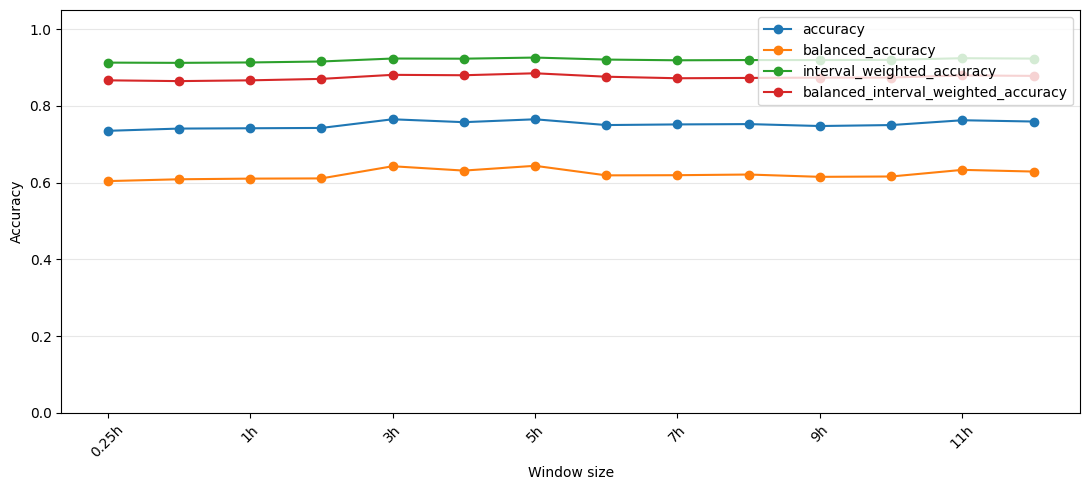

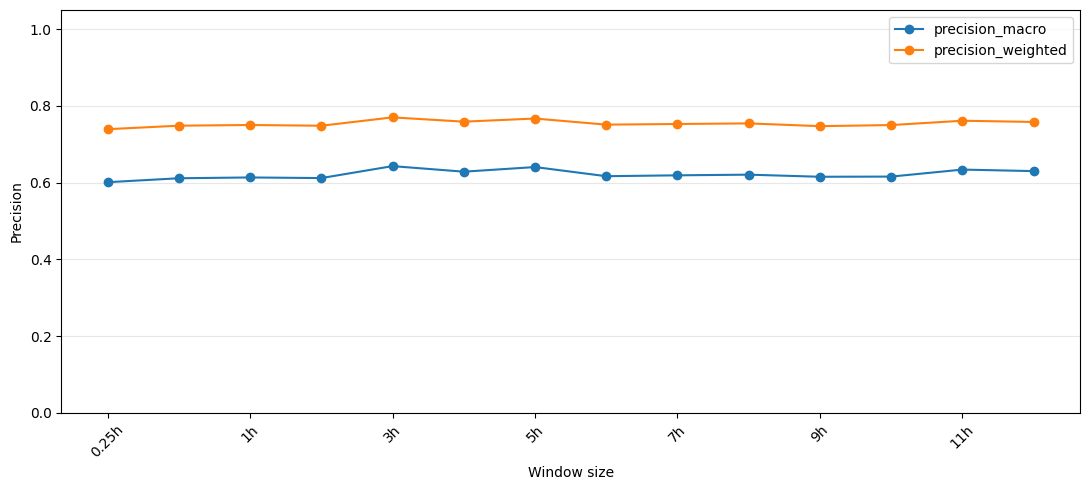

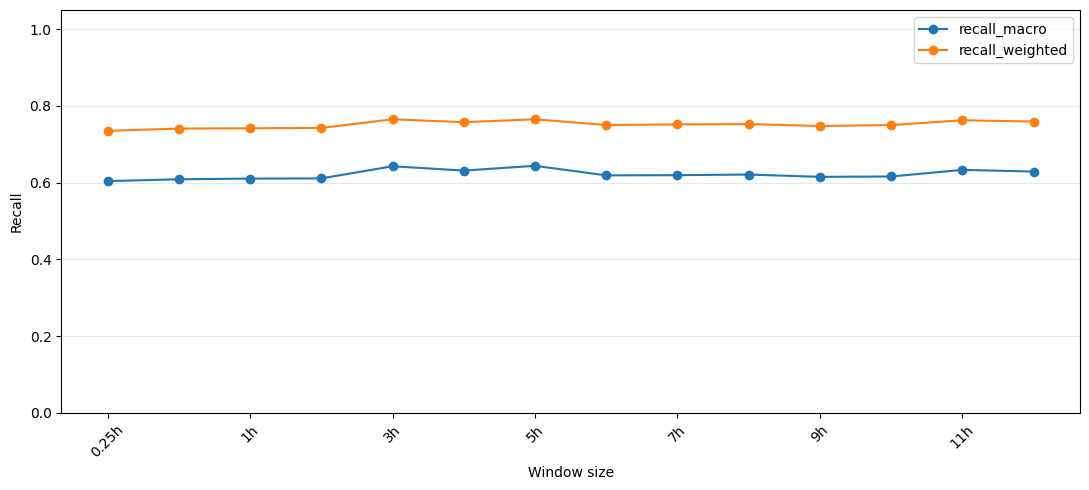

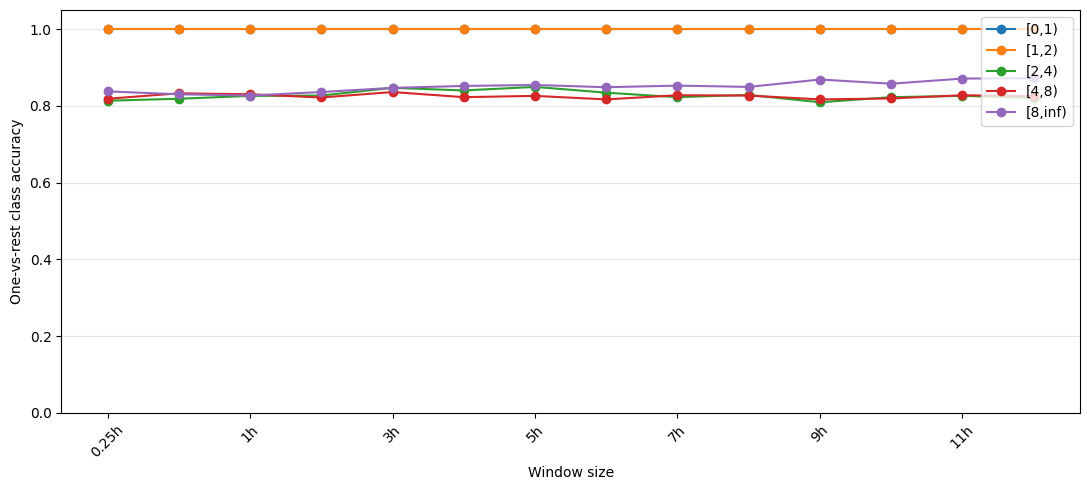

,dataset,winsize,winsize_hours,accuracy,balanced_accuracy,interval_weighted_accuracy,balanced_interval_weighted_accuracy,precision_macro,precision_weighted,recall_macro,recall_weighted
0,dataset_winsize0.25h,0.25h,0.25,0.735171,0.604170,0.912907,0.866762,0.601329,0.739405,0.604170,0.735171
1,dataset_winsize0.5h,0.5h,0.50,0.741019,0.608933,0.912281,0.864726,0.611582,0.748590,0.608933,0.741019
2,dataset_winsize1h,1h,1.00,0.741855,0.610632,0.913325,0.866720,0.613692,0.750341,0.610632,0.741855
3,dataset_winsize2h,2h,2.00,0.742690,0.611180,0.915831,0.870515,0.612083,0.748453,0.611180,0.742690
4,dataset_winsize3h,3h,3.00,0.765246,0.642872,0.923559,0.881046,0.643210,0.770222,0.642872,0.765246


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

interval_metrics_path = (
    Path("model_outputs") / "time_interval_rf" / "all_interval_metrics.csv"
)
interval_df = pd.read_csv(interval_metrics_path)

interval_df["winsize"] = interval_df["dataset"].str.extract(
    r"winsize(.+)$", expand=False
)
interval_df["winsize_hours"] = (
    interval_df["winsize"].str.replace("h", "", regex=False).astype(float)
)
interval_df = interval_df.sort_values("winsize_hours")

class_ids = [0, 1, 2, 3, 4]
class_labels = ["[0,1)", "[1,2)", "[2,4)", "[4,8)", "[8,inf)"]
class_label_by_id = dict(zip(class_ids, class_labels))

metric_rows = []
class_accuracy_rows = []

for row in interval_df.itertuples(index=False):
    prediction_path = (
        Path("model_outputs")
        / "time_interval_rf"
        / row.dataset
        / "rf_test_predictions.csv"
    )
    pred_df = pd.read_csv(prediction_path)
    y_true = pred_df["y_true"].astype(int)
    y_pred = pred_df["y_pred"].astype(int)

    metric_rows.append(
        {
            "dataset": row.dataset,
            "winsize": row.winsize,
            "winsize_hours": row.winsize_hours,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": row.balanced_accuracy,
            "interval_weighted_accuracy": row.interval_weighted_accuracy,
            "balanced_interval_weighted_accuracy": row.balanced_interval_weighted_accuracy,
            "precision_macro": precision_score(
                y_true,
                y_pred,
                labels=class_ids,
                average="macro",
                zero_division=0,
            ),
            "precision_weighted": precision_score(
                y_true,
                y_pred,
                labels=class_ids,
                average="weighted",
                zero_division=0,
            ),
            "recall_macro": recall_score(
                y_true,
                y_pred,
                labels=class_ids,
                average="macro",
                zero_division=0,
            ),
            "recall_weighted": recall_score(
                y_true,
                y_pred,
                labels=class_ids,
                average="weighted",
                zero_division=0,
            ),
        }
    )

    class_accuracy_row = {
        "winsize": row.winsize,
        "winsize_hours": row.winsize_hours,
    }
    for class_id, class_label in class_label_by_id.items():
        true_is_class = y_true == class_id
        pred_is_class = y_pred == class_id
        class_accuracy_row[class_label] = (true_is_class == pred_is_class).mean()
    class_accuracy_rows.append(class_accuracy_row)

interval_metric_df = pd.DataFrame(metric_rows).sort_values("winsize_hours")
per_class_accuracy_df = pd.DataFrame(class_accuracy_rows).sort_values("winsize_hours")

plot_specs = [
    (
        "accuracy",
        [
            "accuracy",
            "balanced_accuracy",
            "interval_weighted_accuracy",
            "balanced_interval_weighted_accuracy",
        ],
        "Accuracy",
        "time_interval_accuracy_metrics.pdf",
    ),
    (
        "precision",
        ["precision_macro", "precision_weighted"],
        "Precision",
        "time_interval_precision_metrics.pdf",
    ),
    (
        "recall",
        ["recall_macro", "recall_weighted"],
        "Recall",
        "time_interval_recall_metrics.pdf",
    ),
]

for _, columns, ylabel, filename in plot_specs:
    ax = interval_metric_df.set_index("winsize")[columns].plot(
        marker="o",
        figsize=(11, 5),
    )
    ax.set_xlabel("Window size")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(Path("output") / filename, dpi=300, bbox_inches="tight")
    plt.show()

ax = per_class_accuracy_df.set_index("winsize")[class_labels].plot(
    marker="o",
    figsize=(11, 5),
)
ax.set_xlabel("Window size")
ax.set_ylabel("One-vs-rest class accuracy")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    Path("output") / "time_interval_per_class_accuracy.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

interval_metric_df.head()

In [8]:
# train a classification model for time intervals
%run train_time_interval_classification.py

             dataset  n_train  n_test  accuracy  balanced_accuracy  interval_weighted_accuracy  balanced_interval_weighted_accuracy  n_[0,1)  n_[1,2)  n_[2,4)  n_[4,8)  n_[8,inf)  accuracy_[0,1)  accuracy_[1,2)  accuracy_[2,4)  accuracy_[4,8)  accuracy_[8,inf)
dataset_winsize0.25h     4786    1197  0.735171           0.604170                    0.912907                             0.866762      538      183      181      179        116             1.0             1.0        0.353591        0.279330          0.387931
 dataset_winsize0.5h     4786    1197  0.741019           0.608933                    0.912281                             0.864726      538      183      181      179        116             1.0             1.0        0.364641        0.335196          0.344828
  dataset_winsize10h     4786    1197  0.750209           0.616208                    0.920217                             0.874003      538      183      181      179        116             1.0             1.0       

# Zone prediction

Endpoint zone-distance stats


,target_label,winsize,model_label,mean_zone_distance,median_zone_distance,p90_zone_distance,same_zone_rate,adjacent_or_same_zone_rate,unreachable_zone_count
0,From-zone classifier,0.25h,Random Forest,2.096,2.0,4.0,0.124,0.258,0
4,From-zone classifier,0.5h,Random Forest,2.123,2.0,4.0,0.113,0.248,0
20,From-zone classifier,1h,Random Forest,2.146,2.0,4.0,0.113,0.262,0
24,From-zone classifier,2h,Random Forest,2.107,2.0,4.0,0.123,0.266,0
28,From-zone classifier,3h,Random Forest,2.068,2.0,4.0,0.119,0.270,0
32,From-zone classifier,4h,Random Forest,2.110,2.0,4.0,0.110,0.272,0
36,From-zone classifier,5h,Random Forest,2.105,2.0,4.0,0.118,0.268,0
40,From-zone classifier,6h,Random Forest,2.105,2.0,4.0,0.119,0.267,0
44,From-zone classifier,7h,Random Forest,2.040,2.0,4.0,0.127,0.284,0
48,From-zone classifier,8h,Random Forest,2.026,2.0,4.0,0.124,0.280,0


Endpoint zone-distance distribution, share of held-out predictions


distance_label                                  0      1      2      3      4  \
target_label         model_label   winsize                                      
From-zone classifier Random Forest 0.25h    0.124  0.135  0.404  0.211  0.114   
                                   0.5h     0.113  0.135  0.416  0.203  0.118   
                                   10h      0.114  0.124  0.414  0.201  0.133   
                                   11h      0.105  0.129  0.431  0.190  0.128   
                                   12h      0.110  0.129  0.442  0.181  0.119   
                                   1h       0.113  0.150  0.381  0.206  0.138   
                                   2h       0.123  0.143  0.393  0.200  0.128   
                                   3h       0.119  0.151  0.409  0.195  0.117   
                                   4h       0.110  0.161  0.402  0.180  0.127   
                                   5h       0.118  0.150  0.404  0.181  0.129   
                                   6h       0.119  0.148  0.396  0.201  0.115   
                                   7h       0.127  0.157  0.409  0.179  0.114   
                                   8h       0.124  0.156  0.423  0.180  0.102   
                                   9h       0.116  0.141  0.409  0.188  0.131   
                     Tree          0.25h    0.089  0.124  0.565  0.167  0.055   
                                   0.5h     0.044  0.114  0.583  0.206  0.049   
                                   10h      0.027  0.149  0.456  0.264  0.077   
                                   11h      0.028  0.136  0.293  0.451  0.062   
                                   12h      0.049  0.084  0.343  0.429  0.079   
                                   1h       0.048  0.072  0.534  0.273  0.053   
                                   2h       0.067  0.169  0.266  0.158  0.289   
                                   3h       0.063  0.118  0.525  0.218  0.066   
                                   4h       0.067  0.109  0.528  0.198  0.089   
                                   5h       0.064  0.113  0.574  0.198  0.044   
                                   6h       0.049  0.097  0.532  0.251  0.055   
                                   7h       0.037  0.129  0.498  0.243  0.063   
                                   8h       0.022  0.160  0.361  0.352  0.089   
                                   9h       0.074  0.158  0.533  0.185  0.047   
To-zone classifier   Random Forest 0.25h    0.124  0.139  0.385  0.211  0.126   
                                   0.5h     0.122  0.138  0.406  0.199  0.124   
                                   10h      0.103  0.136  0.427  0.186  0.135   
                                   11h      0.111  0.137  0.431  0.198  0.112   
                                   12h      0.093  0.140  0.437  0.201  0.119   
                                   1h       0.124  0.155  0.381  0.200  0.127   
                                   2h       0.123  0.138  0.396  0.204  0.128   
                                   3h       0.125  0.144  0.407  0.190  0.123   
                                   4h       0.115  0.168  0.404  0.176  0.122   
                                   5h       0.121  0.146  0.391  0.195  0.129   
                                   6h       0.109  0.144  0.401  0.203  0.125   
                                   7h       0.121  0.155  0.400  0.187  0.121   
                                   8h       0.117  0.147  0.421  0.195  0.103   
                                   9h       0.124  0.128  0.429  0.173  0.135   
                     Tree          0.25h    0.079  0.099  0.548  0.176  0.093   
                                   0.5h     0.068  0.133  0.553  0.175  0.063   
                                   10h      0.084  0.155  0.315  0.372  0.070   
                                   11h      0.019  0.131  0.212  0.520  0.073   
                                   12h      0.048  0.090  0.357  0.419  0.075   
                               

Unordered outage-zone pair distance stats


,winsize,model_label,mean_zone_distance,median_zone_distance,p90_zone_distance,same_zone_rate,adjacent_or_same_zone_rate,unreachable_zone_count
1,0.25h,Random Forest,2.109,2.0,4.0,0.106,0.238,0
3,0.5h,Random Forest,2.111,2.0,4.0,0.100,0.232,0
5,1h,Random Forest,2.119,2.0,4.0,0.096,0.235,0
7,2h,Random Forest,2.107,2.0,4.0,0.101,0.232,0
9,3h,Random Forest,2.071,2.0,3.5,0.092,0.238,0
11,4h,Random Forest,2.088,2.0,4.0,0.079,0.241,0
13,5h,Random Forest,2.110,2.0,4.0,0.089,0.234,0
15,6h,Random Forest,2.126,2.0,3.5,0.074,0.225,0
17,7h,Random Forest,2.058,2.0,3.5,0.081,0.251,0
19,8h,Random Forest,2.047,2.0,3.0,0.076,0.231,0


Unordered outage-zone pair distance distribution, share of held-out predictions


distance_label             0    0.5      1    1.5      2    2.5      3    3.5  \
model_label   winsize                                                           
Random Forest 0.25h    0.106  0.008  0.124  0.036  0.358  0.047  0.194  0.016   
              0.5h     0.100  0.009  0.123  0.033  0.373  0.048  0.193  0.011   
              10h      0.066  0.018  0.116  0.069  0.351  0.077  0.170  0.033   
              11h      0.067  0.017  0.121  0.057  0.368  0.089  0.169  0.029   
              12h      0.062  0.017  0.122  0.056  0.378  0.094  0.158  0.020   
              1h       0.096  0.011  0.128  0.044  0.347  0.057  0.190  0.017   
              2h       0.101  0.011  0.120  0.045  0.352  0.061  0.179  0.025   
              3h       0.092  0.018  0.128  0.050  0.355  0.075  0.162  0.022   
              4h       0.079  0.026  0.136  0.052  0.357  0.065  0.158  0.026   
              5h       0.089  0.022  0.123  0.053  0.342  0.063  0.179  0.025   
              6h       0.074  0.025  0.126  0.058  0.333  0.084  0.180  0.024   
              7h       0.081  0.024  0.146  0.058  0.344  0.068  0.160  0.024   
              8h       0.076  0.022  0.133  0.080  0.341  0.084  0.169  0.019   
              9h       0.077  0.019  0.121  0.064  0.348  0.082  0.173  0.016   
Tree          0.25h    0.061  0.009  0.088  0.069  0.501  0.083  0.100  0.036   
              0.5h     0.030  0.009  0.081  0.109  0.517  0.049  0.134  0.023   
              10h      0.015  0.015  0.050  0.154  0.236  0.333  0.135  0.018   
              11h      0.002  0.019  0.030  0.116  0.158  0.221  0.353  0.038   
              12h      0.047  0.002  0.084  0.002  0.342  0.024  0.405  0.006   
              1h       0.008  0.011  0.033  0.109  0.215  0.332  0.191  0.050   
              2h       0.033  0.024  0.126  0.080  0.195  0.101  0.109  0.253   
              3h       0.063  0.000  0.110  0.013  0.511  0.016  0.211  0.001   
              4h       0.039  0.000  0.117  0.033  0.450  0.069  0.174  0.018   
              5h       0.045  0.000  0.097  0.036  0.505  0.095  0.156  0.022   
              6h       0.026  0.009  0.081  0.073  0.413  0.174  0.147  0.025   
              7h       0.033  0.001  0.125  0.013  0.477  0.025  0.229  0.006   
              8h       0.003  0.005  0.043  0.160  0.303  0.271  0.129  0.029   
              9h       0.063  0.000  0.130  0.046  0.495  0.069  0.142  0.008   

distance_label             4    4.5      5  
model_label   winsize                       
Random Forest 0.25h    0.096  0.006  0.009  
              0.5h     0.096  0.007  0.008  
              10h      0.089  0.006  0.006  
              11h      0.074  0.004  0.006  
              12h      0.083  0.004  0.008  
              1h       0.096  0.007  0.008  
              2h       0.095  0.004  0.007  
              3h       0.087  0.007  0.004  
              4h       0.087  0.005  0.010  
              5h       0.088  0.004  0.013  
              6h       0.078  0.005  0.013  
              7h       0.082  0.005  0.008  
              8h       0.063  0.005  0.009  
              9h       0.092  0.003  0.004  
Tree          0.25h    0.048  0.003  0.001  
              0.5h     0.039  0.006  0.002  
              10h      0.026  0.016  0.003  
              11h      0.041  0.001  0.021  
              12h      0.074  0.003  0.011  
              1h       0.014  0.021  0.016  
              2h       0.032  0.043  0.004  
              3h       0.065  0.001  0.009  
              4h       0.079  0.011  0.010  
              5h       0.031  0.009  0.004  
              6h       0.028  0.013  0.012  
              7h       0.060  0.001  0.030  
              8h       0.043  0.012  0.003  
              9h       0.040  0.003  0.003

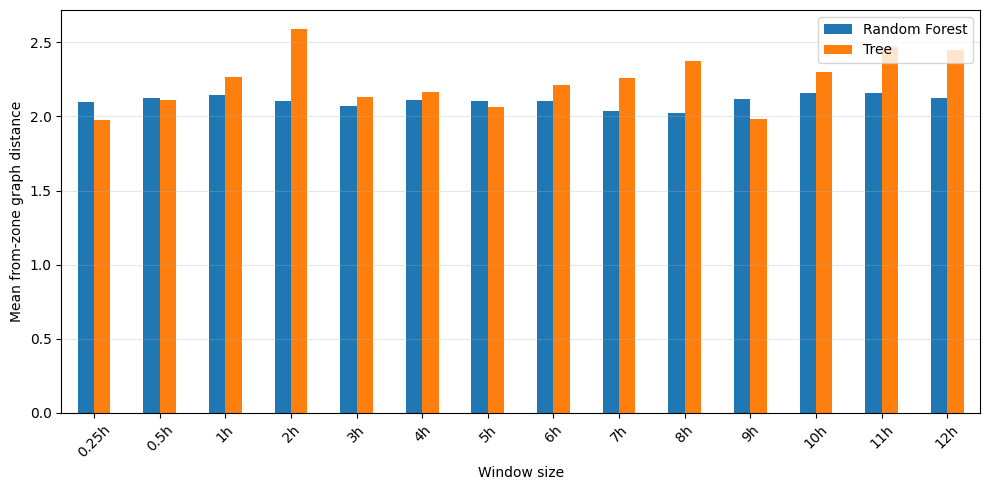

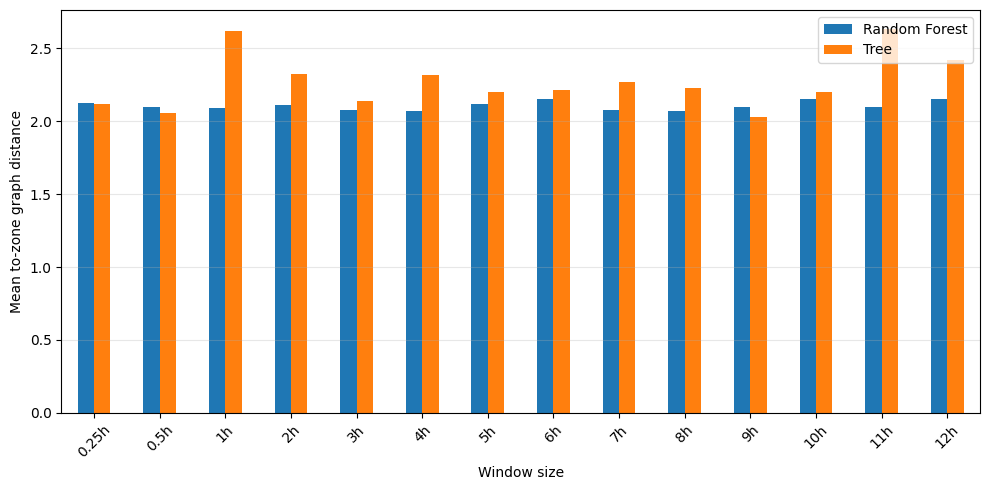

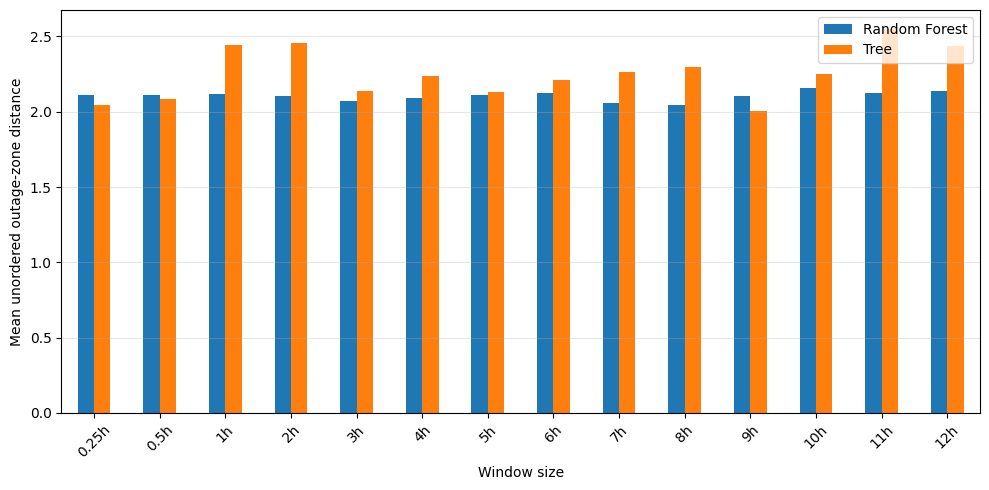

,dataset,winsize,winsize_hours,model,model_label,mean_zone_distance,median_zone_distance,p90_zone_distance,same_zone_rate,adjacent_or_same_zone_rate,unreachable_zone_count
1,dataset_winsize0.25h,0.25h,0.25,rf,Random Forest,2.109440,2.0,4.0,0.106099,0.238095,0
3,dataset_winsize0.5h,0.5h,0.50,rf,Random Forest,2.111111,2.0,4.0,0.100251,0.232247,0
5,dataset_winsize1h,1h,1.00,rf,Random Forest,2.118630,2.0,4.0,0.096074,0.234754,0
7,dataset_winsize2h,2h,2.00,rf,Random Forest,2.106516,2.0,4.0,0.101086,0.232247,0
9,dataset_winsize3h,3h,3.00,rf,Random Forest,2.071011,2.0,3.5,0.091896,0.238095,0


In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import deque
from IPython.display import display

ZONE_DATA_DIR = Path(globals().get("DATA_DIR", "output"))
ZONE_MODEL_OUTPUT_DIR = ZONE_DATA_DIR.parent / "model_outputs"
ZONE_SUMMARY_FILENAME = "all_metrics_summary.csv"
ZONE_DROP_COLUMNS = [
    "fold_id",
    "label_is_auto",
    "label_time_to_event_seconds",
    "label_from_zone",
    "label_to_zone",
]
ZONE_MODEL_LABELS = {"tree": "Tree", "rf": "Random Forest"}
zone_metrics_df = pd.read_csv(ZONE_MODEL_OUTPUT_DIR / ZONE_SUMMARY_FILENAME)

ZONE_TARGETS = ["label_from_zone", "label_to_zone"]
ZONE_TARGET_LABELS = {
    "label_from_zone": "From-zone classifier",
    "label_to_zone": "To-zone classifier",
}


def build_zone_distance_lookup(edge_zone_path):
    edge_zone_df = pd.read_csv(edge_zone_path)
    zones = sorted(
        set(edge_zone_df["from_zone"].astype(int))
        | set(edge_zone_df["to_zone"].astype(int))
    )
    adjacency = {zone: {zone} for zone in zones}

    for from_zone, to_zone in zip(
        edge_zone_df["from_zone"].astype(int),
        edge_zone_df["to_zone"].astype(int),
    ):
        adjacency.setdefault(from_zone, {from_zone}).add(to_zone)
        adjacency.setdefault(to_zone, {to_zone}).add(from_zone)

    distances = {}
    for source in adjacency:
        source_distances = {source: 0}
        queue = deque([source])
        while queue:
            current = queue.popleft()
            for neighbor in adjacency[current]:
                if neighbor not in source_distances:
                    source_distances[neighbor] = source_distances[current] + 1
                    queue.append(neighbor)
        distances[source] = source_distances

    return distances


def zone_graph_distances(y_true, y_pred, distance_lookup):
    values = []
    for true_zone, pred_zone in zip(y_true, y_pred):
        true_zone = int(true_zone)
        pred_zone = int(pred_zone)
        values.append(distance_lookup.get(true_zone, {}).get(pred_zone, np.nan))
    return np.asarray(values, dtype=float)


def summarize_zone_distances(distances):
    finite_distances = distances[np.isfinite(distances)]
    if len(finite_distances) == 0:
        return {
            "mean_zone_distance": np.nan,
            "median_zone_distance": np.nan,
            "p90_zone_distance": np.nan,
            "same_zone_rate": np.nan,
            "adjacent_or_same_zone_rate": np.nan,
            "unreachable_zone_count": int(np.isnan(distances).sum()),
        }

    return {
        "mean_zone_distance": finite_distances.mean(),
        "median_zone_distance": np.median(finite_distances),
        "p90_zone_distance": np.percentile(finite_distances, 90),
        "same_zone_rate": (finite_distances == 0).mean(),
        "adjacent_or_same_zone_rate": (finite_distances <= 1).mean(),
        "unreachable_zone_count": int(np.isnan(distances).sum()),
    }


def zone_distance_distribution_rows(distances, base_row):
    distances = np.asarray(distances, dtype=float)
    finite_distances = distances[np.isfinite(distances)]
    total_count = len(distances)
    rows = []

    for distance, count in (
        pd.Series(finite_distances).value_counts().sort_index().items()
    ):
        rows.append(
            {
                **base_row,
                "zone_distance": float(distance),
                "distance_label": f"{distance:g}",
                "count": int(count),
                "share": count / total_count if total_count > 0 else np.nan,
            }
        )

    unreachable_count = int(np.isnan(distances).sum())
    if unreachable_count > 0:
        rows.append(
            {
                **base_row,
                "zone_distance": np.nan,
                "distance_label": "unreachable",
                "count": unreachable_count,
                "share": unreachable_count / total_count if total_count > 0 else np.nan,
            }
        )

    return rows


def predict_zone_target(dataset, target, model_name):
    dataset_path = ZONE_DATA_DIR / f"{dataset}.csv"
    model_path = ZONE_MODEL_OUTPUT_DIR / dataset / target / f"{model_name}.joblib"
    if not dataset_path.exists():
        raise FileNotFoundError(f"Missing dataset: {dataset_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Missing saved model: {model_path}")

    df = pd.read_csv(dataset_path)
    test_df = df[df["fold_id"] == -1].copy()
    y_test = test_df[target]
    test_mask = y_test.notna()

    y_test = y_test.loc[test_mask].astype(int)
    X_test = test_df.drop(
        columns=[c for c in ZONE_DROP_COLUMNS if c in test_df.columns]
    )
    X_test = X_test.select_dtypes(include=[np.number, "bool"]).loc[test_mask]

    model = joblib.load(model_path)
    y_pred = pd.Series(model.predict(X_test), index=y_test.index).astype(int)

    return y_test, y_pred


def unordered_zone_pair_distances(
    true_from,
    true_to,
    pred_from,
    pred_to,
    distance_lookup,
):
    from_to = zone_graph_distances(true_from, pred_from, distance_lookup)
    to_to = zone_graph_distances(true_to, pred_to, distance_lookup)
    from_to_swapped = zone_graph_distances(true_from, pred_to, distance_lookup)
    to_to_swapped = zone_graph_distances(true_to, pred_from, distance_lookup)

    direct = (from_to + to_to) / 2
    swapped = (from_to_swapped + to_to_swapped) / 2

    return np.nanmin(np.vstack([direct, swapped]), axis=0)


zone_distance_lookup = build_zone_distance_lookup(ZONE_DATA_DIR / "edge_zones.csv")

zone_class_df = zone_metrics_df[
    (zone_metrics_df["task"] == "classification")
    & (zone_metrics_df["target"].isin(ZONE_TARGETS))
    & (zone_metrics_df["model"].isin(["tree", "rf"]))
].copy()

zone_class_df["winsize"] = zone_class_df["dataset"].str.extract(
    r"winsize(.+)$", expand=False
)
zone_class_df["winsize_hours"] = (
    zone_class_df["winsize"].str.replace("h", "", regex=False).astype(float)
)

zone_distance_rows = []
zone_distance_distribution = []
zone_prediction_cache = {}

for row in zone_class_df.sort_values(["dataset", "target", "model"]).itertuples(
    index=False
):
    y_true, y_pred = predict_zone_target(row.dataset, row.target, row.model)
    distances = zone_graph_distances(y_true, y_pred, zone_distance_lookup)
    zone_prediction_cache[(row.dataset, row.target, row.model)] = (y_true, y_pred)

    base_row = {
        "dataset": row.dataset,
        "winsize": row.winsize,
        "winsize_hours": row.winsize_hours,
        "target": row.target,
        "target_label": ZONE_TARGET_LABELS[row.target],
        "model": row.model,
        "model_label": ZONE_MODEL_LABELS.get(row.model, row.model),
    }
    zone_distance_rows.append({**base_row, **summarize_zone_distances(distances)})
    zone_distance_distribution.extend(
        zone_distance_distribution_rows(distances, base_row)
    )

zone_distance_df = pd.DataFrame(zone_distance_rows).sort_values(
    ["target", "model", "winsize_hours"]
)
zone_distance_distribution_df = pd.DataFrame(zone_distance_distribution).sort_values(
    ["target", "model", "winsize_hours", "zone_distance"],
    na_position="last",
)
zone_distance_df.to_csv(
    ZONE_MODEL_OUTPUT_DIR / "zone_endpoint_distance_summary.csv",
    index=False,
)
zone_distance_distribution_df.to_csv(
    ZONE_MODEL_OUTPUT_DIR / "zone_endpoint_distance_distribution.csv",
    index=False,
)

pair_distance_rows = []
pair_distance_distribution = []
for dataset, model_name in (
    zone_class_df[["dataset", "model"]].drop_duplicates().itertuples(index=False)
):
    from_true, from_pred = zone_prediction_cache[
        (dataset, "label_from_zone", model_name)
    ]
    to_true, to_pred = zone_prediction_cache[(dataset, "label_to_zone", model_name)]

    shared_index = from_true.index.intersection(to_true.index)
    pair_distances = unordered_zone_pair_distances(
        from_true.loc[shared_index],
        to_true.loc[shared_index],
        from_pred.loc[shared_index],
        to_pred.loc[shared_index],
        zone_distance_lookup,
    )

    dataset_rows = zone_class_df[
        (zone_class_df["dataset"] == dataset) & (zone_class_df["model"] == model_name)
    ]
    winsize = dataset_rows["winsize"].iloc[0]
    winsize_hours = dataset_rows["winsize_hours"].iloc[0]

    base_row = {
        "dataset": dataset,
        "winsize": winsize,
        "winsize_hours": winsize_hours,
        "model": model_name,
        "model_label": ZONE_MODEL_LABELS.get(model_name, model_name),
    }
    pair_distance_rows.append({**base_row, **summarize_zone_distances(pair_distances)})
    pair_distance_distribution.extend(
        zone_distance_distribution_rows(pair_distances, base_row)
    )

zone_pair_distance_df = pd.DataFrame(pair_distance_rows).sort_values(
    ["model", "winsize_hours"]
)
zone_pair_distance_distribution_df = pd.DataFrame(
    pair_distance_distribution
).sort_values(
    ["model", "winsize_hours", "zone_distance"],
    na_position="last",
)
zone_pair_distance_df.to_csv(
    ZONE_MODEL_OUTPUT_DIR / "zone_pair_distance_summary.csv",
    index=False,
)
zone_pair_distance_distribution_df.to_csv(
    ZONE_MODEL_OUTPUT_DIR / "zone_pair_distance_distribution.csv",
    index=False,
)

stat_columns = [
    "winsize",
    "model_label",
    "mean_zone_distance",
    "median_zone_distance",
    "p90_zone_distance",
    "same_zone_rate",
    "adjacent_or_same_zone_rate",
    "unreachable_zone_count",
]

print("Endpoint zone-distance stats")
display(
    zone_distance_df.sort_values(["target_label", "model_label", "winsize_hours"])[
        ["target_label", *stat_columns]
    ].round(3)
)

print("Endpoint zone-distance distribution, share of held-out predictions")
display(
    zone_distance_distribution_df.pivot_table(
        index=["target_label", "model_label", "winsize"],
        columns="distance_label",
        values="share",
        fill_value=0,
    ).round(3)
)

print("Unordered outage-zone pair distance stats")
display(
    zone_pair_distance_df.sort_values(["model_label", "winsize_hours"])[
        stat_columns
    ].round(3)
)

print("Unordered outage-zone pair distance distribution, share of held-out predictions")
display(
    zone_pair_distance_distribution_df.pivot_table(
        index=["model_label", "winsize"],
        columns="distance_label",
        values="share",
        fill_value=0,
    ).round(3)
)

endpoint_plot_specs = [
    (
        "label_from_zone",
        "Mean from-zone graph distance",
        "zone_from_mean_distance.pdf",
    ),
    (
        "label_to_zone",
        "Mean to-zone graph distance",
        "zone_to_mean_distance.pdf",
    ),
]

for target, ylabel, filename in endpoint_plot_specs:
    target_data = zone_distance_df[zone_distance_df["target"] == target]
    winsize_order = target_data.sort_values("winsize_hours").drop_duplicates("winsize")[
        "winsize"
    ]
    pivot = target_data.pivot(
        index="winsize", columns="model_label", values="mean_zone_distance"
    ).reindex(winsize_order)

    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_xlabel("Window size")
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(ZONE_DATA_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

winsize_order = zone_pair_distance_df.sort_values("winsize_hours").drop_duplicates(
    "winsize"
)["winsize"]
pair_pivot = zone_pair_distance_df.pivot(
    index="winsize", columns="model_label", values="mean_zone_distance"
).reindex(winsize_order)

ax = pair_pivot.plot(kind="bar", figsize=(10, 5))
ax.set_xlabel("Window size")
ax.set_ylabel("Mean unordered outage-zone distance")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(
    ZONE_DATA_DIR / "zone_pair_mean_distance.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

zone_pair_distance_df.head()